<h1 style="text-align: center;">TP - Construire ses premiers réseaux de neurones (RNN) réseaux de convolutions (CNN) </h1>

Dans ce TP nous allons apprendre à créer un réseau de neurones pas à pas. Tout d'abord nous introduisons un modèle simple avec une chaîne très simple afin de bien comprendre les composants du réseau. Par la suite nous l'étendons pour le mettre dans une chaîne de traitement complète qui va permettre de créer un modèle qui peut être mis en production.   

La seconde partie du TP concerne les réseaux de convolutions. Nous verrons comment mettre en place un classifieur pour classer des images.   

Les jeux de données sont réduits pour éviter de perdre trop de temps en apprentissage. Il est important de bien réaliser différentes expérimentations. Ce n'est pas parce que le réseau fonctionne qu'il donne le meilleur résultat donc prenez votre temps pour bien faire varier les composants de vos réseaux et voir leur impact.   

**Remarque :** Le TP n'est pas difficile. Il suffit de le faire progressivement. Il peut être fait en 5 minutes avec ChatGPT ou Copilot mais pensez vous que ce soit utile ? apprenez bien comment fonctionnent les réseaux, leurs composants, comment les évaluer, si vous n'introduisez pas de biais, etc.  Posez vous les bonnes questions et sachez y répondre. N'utilisez pas bêtement une IA générative où après vous serez incapable d'avancer car vous ne maîtrisez pas les bases. Il n'y a vraiment rien de difficile mais c'est important de bien le faire. Vous verrez d'ailleurs que dans ce TP il y a une partie qui a été faite par une IA ... il s'agit juste de fonctions d'affichage que tout le monde sait très bien faire et qui n'apportent aucune connaissance ou compétence supplémentaire :)


# Environnement

Ce notebook peut fonctionner sur plusieurs environnement `Jupyter`. Cependant il est préférable d'utiliser un environnement disposant de GPU. Pour cela il est recommandé d'utiliser Colab.  

**Pour les utilisateurs de Colab :**

Pour pouvoir utiliser votre répertoire `Google Drive`, il est nécessaire de fournir une autorisation. Pour cela, si elle est en commentaire, il suffit de décommenter et d'exécuter la cellule suivante.

In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

ModuleNotFoundError: No module named 'google'

Décommenter, si nécessaire, les lignes et corriger la ligne `my_local_drive` pour mettre le chemin vers un répertoire spécifique de votre répertoire Google Drive.

In [ ]:
import sys
my_local_drive='/content/gdrive/My Drive/Colab Notebooks/ML_FDS'
sys.path.append(my_local_drive)

Il faut décommenter, si nécessaire, la ligne suivante pour se positionner dans le répertoire associé.

In [2]:
#%cd $my_local_drive


Defaulting to user installation because normal site-packages is not writeable
  Using cached pandas-2.3.3-cp310-cp310-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (12.8 MB)


# Installation

**Remarque :** toutes les bibliothèques sont importées au début pour faciliter la lecture.

In [2]:
import os
import numpy as np
import pandas as pd
import random
import zipfile
import cv2
from sklearn.datasets import make_moons
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import joblib

import tensorflow as tf
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Pour définir la graine tout de suite
np.random.seed(42)
tf.random.set_seed(42)

2026-03-22 15:35:48.065619: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-22 15:35:48.089680: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-22 15:35:48.827499: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-22 15:35:51.894745: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

La cellule suivante contient des fonctions de visualisation qui seront utilisées pendant le TP.   

**Remarque :** pour information la cellule suivante a été générée par ChatGPT. Ne perdons pas de temps pour les fonctions de visualisations que vous savez faire. Il faut se focaliser sur le modèle et comment il fonctionne.

In [3]:
# Cellule générée par ChatGPT

def plot_history_simple(history):
    """
    Trace côte à côte les courbes Loss et Accuracy (train/val si dispo)
    à partir d'un objet Keras History.
    """
    hist = history.history

    # compatibilité anciennes versions ("acc"/"val_acc")
    acc_key = "accuracy" if "accuracy" in hist else "acc"
    val_acc_key = "val_accuracy" if "val_accuracy" in hist else "val_acc"

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # --- Loss ---
    if "loss" in hist:
        axes[0].plot(hist["loss"], label="train")
    if "val_loss" in hist:
        axes[0].plot(hist["val_loss"], label="val")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    # --- Accuracy ---
    if acc_key in hist:
        axes[1].plot(hist[acc_key], label="train")
        if val_acc_key in hist:
            axes[1].plot(hist[val_acc_key], label="val")
        axes[1].set_title("Accuracy")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("Accuracy")
        axes[1].legend()
    else:
        axes[1].set_visible(False)  # si pas d'accuracy, on masque le 2e plot

    plt.tight_layout()
    plt.show()



def plot_confusion_matrix_simple(y_true, y_pred, labels=(0,1),
                                 normalize=None, title="Confusion matrix"):
    """
    Affiche une matrice de confusion.
    Args:
        y_true, y_pred : vecteurs de labels
        labels         : ordre des classes à afficher
        normalize      : None, 'true', 'pred', ou 'all' (comme scikit-learn)
        title          : titre de la figure
    """
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize=normalize)
    fig, ax = plt.subplots(1, 1, figsize=(4, 4))
    im = ax.imshow(cm, interpolation='nearest')
    ax.figure.colorbar(im, ax=ax)

    ax.set(
        xticks=np.arange(len(labels)),
        yticks=np.arange(len(labels)),
        xticklabels=labels,
        yticklabels=labels,
        xlabel="Predicted label",
        ylabel="True label",
      title=title if normalize is None else f"{title} (normalized: {normalize})"
    )

    # annotations
    thresh = cm.max() / 2.0 if cm.size else 0.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            txt = f"{cm[i, j]:.2f}" if normalize else f"{int(cm[i, j])}"
            ax.text(j, i, txt,
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.show()

def plot_history_cv_mean_std(all_histories, alpha=0.2):
    """
    all_histories : list[pd.DataFrame]
        Chaque DF doit contenir : ['accuracy','loss','val_accuracy','val_loss','epoch','fold'].
        (c'est exactement ton format actuel)

    Trace loss et accuracy (train/val) avec moyenne ± écart-type par epoch.
    Si certains folds s'arrêtent plus tôt (early stopping), la moyenne/STD
    sur les dernières époques est calculée sur les folds encore présents.
    """
    import pandas as pd
    import matplotlib.pyplot as plt

    # 1) Concat & agrégation
    df = pd.concat(all_histories, ignore_index=True)
    cols = [c for c in ["loss", "val_loss", "accuracy", "val_accuracy"] if c in df.columns]
    stats = df.groupby("epoch")[cols].agg(["mean", "std"])
    stats.columns = [f"{m}_{s}" for m, s in stats.columns]  # ex: ('loss','mean')->'loss_mean'
    stats = stats.reset_index()
    epochs = stats["epoch"].values

    # 2) Plot côte à côte
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # --- Loss ---
    if "loss_mean" in stats:
        axes[0].plot(epochs, stats["loss_mean"].to_numpy(), label="train")
        if "loss_std" in stats:
            axes[0].fill_between(epochs, stats["loss_mean"]-stats["loss_std"],
                                          stats["loss_mean"]+stats["loss_std"], alpha=alpha)
    if "val_loss_mean" in stats:
        axes[0].plot(epochs, stats["val_loss_mean"].to_numpy(), label="val")
        if "val_loss_std" in stats:
            axes[0].fill_between(epochs, stats["val_loss_mean"]-stats["val_loss_std"],
                                          stats["val_loss_mean"]+stats["val_loss_std"], alpha=alpha)
    axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()

    # --- Accuracy ---
    if "accuracy_mean" in stats:
        axes[1].plot(epochs, stats["accuracy_mean"].to_numpy(), label="train")
        if "accuracy_std" in stats:
            axes[1].fill_between(epochs, stats["accuracy_mean"]-stats["accuracy_std"],
                                          stats["accuracy_mean"]+stats["accuracy_std"], alpha=alpha)
    if "val_accuracy_mean" in stats:
        axes[1].plot(epochs, stats["val_accuracy_mean"].to_numpy(), label="val")
        if "val_accuracy_std" in stats:
            axes[1].fill_between(epochs, stats["val_accuracy_mean"]-stats["val_accuracy_std"],
                                          stats["val_accuracy_mean"]+stats["val_accuracy_std"], alpha=alpha)
    axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()

    plt.tight_layout()
    plt.show()

def plot_decision_boundary(pipe, X, y=None, title=None, h=0.02, padding=0.5, threshold=0.5, ax=None):
    """
    Affiche la frontière de décision d'un modèle 2D (ex: make_moons).
    pipe : Pipeline déjà fit (ex: StandardScaler + KerasClassifier)
    X, y : données à superposer (y optionnel pour juste la frontière)
    h : pas de la grille, padding : marge autour des données
    threshold : seuil de classification si proba disponible
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(6,5))

    # -- Grille 2D
    x_min, x_max = X[:,0].min()-padding, X[:,0].max()+padding
    y_min, y_max = X[:,1].min()-padding, X[:,1].max()+padding
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    grid = np.c_[xx.ravel(), yy.ravel()]

    # -- Prédiction robuste (proba > decision_function > predict)
    Z = None
    if hasattr(pipe, "predict_proba"):
        proba = pipe.predict_proba(grid)
        # binaire : colonnes [p(classe0), p(classe1)] ou vecteur
        Z = proba[:,1] if proba.ndim == 2 and proba.shape[1] > 1 else proba.ravel()
    elif hasattr(pipe, "decision_function"):
        s = pipe.decision_function(grid).ravel()
        # Normalisation sigmoïde légère sans SciPy
        Z = 1 / (1 + np.exp(-s))
    else:
        # chute de secours : classes {0,1}
        Z = pipe.predict(grid).ravel().astype(float)

    Z_grid = Z.reshape(xx.shape)

    # -- Fond coloré + ligne de frontière
    # si Z est proba, on trace la courbe de niveau au seuil; sinon on sépare 0/1
    if np.unique(Z).size > 2 or (Z.min() >= 0 and Z.max() <= 1):
        ax.contourf(xx, yy, Z_grid, levels=50, alpha=0.25)
        ax.contour(xx, yy, (Z_grid >= threshold).astype(int), levels=[0.5], colors="k", linewidths=1)
    else:
        ax.contourf(xx, yy, Z_grid, levels=[-0.5,0.5,1.5], alpha=0.25)
        ax.contour(xx, yy, Z_grid, levels=[0.5], colors="k", linewidths=1)

    # -- Nuage de points (si y fourni)
    if y is not None:
        ax.scatter(X[:,0], X[:,1], c=y, s=25, edgecolor="k", linewidth=0.5)

    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    if title:
        ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
    plt.tight_layout()
    return ax

def plot_examples(X,y,nb_columns=25):
  plt.figure(figsize=(15,15))
  for i in range(nb_columns):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    # cv2 lit met les images en BGR et matplotlib lit du RGB
    X[i] = cv2.cvtColor(X[i], cv2.COLOR_BGR2RGB)
    plt.imshow(X[i]/255.,cmap=plt.cm.binary)
    plt.xlabel('classe ' + str(y[i]))

Exécutez la cellule suivante. Attention c'est un peu long.

In [51]:
zip_file="Tiger-Fox-Elephant.zip"
!wget https://www.lirmm.fr/~poncelet/Ressources/Tiger-Fox-Elephant.zip


with zipfile.ZipFile(zip_file,"r") as zip_ref:
    zip_ref.extractall("Data_Project")

# Suppression du fichier ZIP après extraction pour économiser de l'espace
os.remove(zip_file)

--2026-03-22 15:54:24--  https://www.lirmm.fr/~poncelet/Ressources/Data_humanface_cat_without_caption_400.zip
Resolving www.lirmm.fr (www.lirmm.fr)... 193.49.104.251
Connecting to www.lirmm.fr (www.lirmm.fr)|193.49.104.251|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 17046657 (16M) [application/zip]
Saving to: ‘Data_humanface_cat_without_caption_400.zip’

Data_humanface_cat_ 100%[===================>]  16.26M  6.12MB/s    in 2.7s    

2026-03-22 15:54:26 (6.12 MB/s) - ‘Data_humanface_cat_without_caption_400.zip’ saved [17046657/17046657]



# Réseau de Neurones

## Le jeu de données

Pour illustrer le fonctionnement d'un réseau de neurones nous allons utiliser un jeu de données simple à l'aide la fonction `make_moons`. La cellule ci-dessous vous montre comment l'utiliser. Vous pouvez l'utiliser tel quel ou bien faire varier les paramètres pour avoir des données encore plus complexes à classer. Par la suite, quand vous aurez défini vos modèles vous pourrez également les tester avec `make_circle` dont l'utilisation est précisée en dessous (attention code mis en commentaire).

In [7]:
X, y = make_moons(n_samples=3000, noise=0.25, random_state=42)

Quelques informations sur les données

X shape: (3000, 2)  | y shape: (3000,)
Un exemple des données dans X [-0.13595251 -0.23463184]
Un exemple des données dans y 1
Distributions des classe: (3000, 2) {0: 1500, 1: 1500}


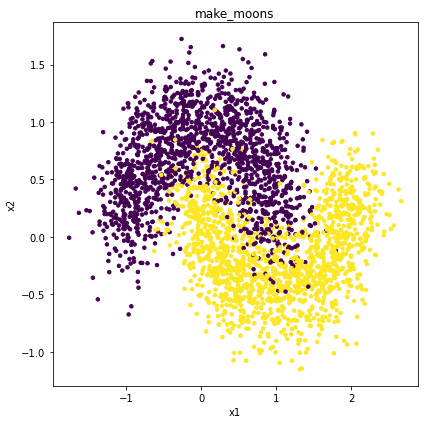

In [8]:
print("X shape:", X.shape, " | y shape:", y.shape)
print ("Un exemple des données dans X", X[0])
print ("Un exemple des données dans y", y[0])

u, c = np.unique(y, return_counts=True)
print("Distributions des classe:", X.shape, dict(zip(map(int, u), map(int, c))))

plt.figure(figsize=(6,6))
plt.scatter(X[:, 0], X[:, 1], c=y, s=12)
plt.title("make_moons")
plt.xlabel("x1"); plt.ylabel("x2")
plt.tight_layout()
plt.show()

In [9]:
#X, y = make_circles(n_samples=1000, noise=0.08, factor=0.15, random_state=42)

#print("X shape:", X.shape, " | y shape:", y.shape)
#u, c = np.unique(y, return_counts=True)
#print("Distributions:", X.shape, dict(zip(map(int, u), map(int, c))))

#plt.figure(figsize=(5,5))
#plt.scatter(X[:,0], X[:,1], c=y, s=12)
#plt.title("make_circles : centre + anneau")
#plt.axis("equal"); plt.tight_layout(); plt.show()


## Un premier réseau de neurones simple

Dans un premier temps nous allons considérer une simple classification pour apprendre à écrire un modèle. En d'autres termes au début il suffit d'utiliser `train_test_split` et de normaliser.  

**Attention :** Jusqu'à présent, nous avons parfois normalisé en utilisant tout `X` (ou directement `X_train` et `X_test`) et fait par exemple `scaler.fit(X)`. Cette simplification servait à aller vite et à se concentrer sur d'autres points du cours. En réalité, un scaler comme `StandardScaler` apprend des paramètres (la moyenne μ et l'écart-type σ) au moment du `fit`. Si l'on calcule μ et σ en incluant les données de validation ou de test, on laisse “fuiter” des informations du futur vers l'entraînement (cela s'appelle du *data leakage*) : le modèle voit indirectement le test, ce qui biaise l'évaluation et rend les scores artificiellement trop bons.   
La bonne pratique consiste donc à faire `scaler.fit(X_train)` uniquement sur les données d'apprentissage, puis à appliquer la transformation avec `scaler.transform(...)` à `X_train`, `X_test` et aussi `X_val` s'il est utilisé.  
 Attention, le même principe s'applique en cross-validation : pour chaque fold, on ajuste la normalisation sur le sous-ensemble d'entraînement du fold, puis on transforme le sous-ensemble de validation correspondant.

In [10]:
# Complétez les lignes

# Découpage en jeu d'apprentissage et de test

X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.3,stratify=y)
# Ne pas oublier de normaliser.
# Attention toujours faire le fit sur le X_train et les transform
scaler = StandardScaler() #normalisation
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test= scaler.transform(X_test)

A présent nous passons à la définition du modèle. Préférez utiliser la notation fonctionnelle pour prendre l'habitude.

Trouvez d'abord combien de dimensions sont en entrée du modèle (vous avez la réponse au dessus !). Il faut ensuite créer un modèle qui prend en entrée ce nombre de dimensions, qui contient deux couches denses avec 32 neurones et une fonction d'activation. Réfléchissez bien au format de la couche de sortie (c'est une classification binaire). N'oubliez pas de réfléchir également aux fonctions d'activations à utiliser.

**Remarque :** prenez l'habitude de nommer vos couches. Il y a un double intérêt :    
- le premier est lié au fait qu'à chaque fois que vous allez relancer le modèle un nouveau numéro sera attribué à la couche et vous aurez du mal à les retrouver.
- le second plus important, vous verrez plus tard que parfois vous devrez récupérer la sortie d'une couche et c'est beaucoup plus simple d'utiliser quelque chose comme `monmodele.get_layer("lenomdemacouche")`.

In [11]:
# Complétez les lignes manquantes
input_dim=2


inputs = Input(shape=(2,))
#1ere couche 
x = Dense(32, activation="relu",name="1erecouche")(inputs)
#2eme couche 
x= Dense(32, activation="relu",name="2emecouche")(x)
#relu = hidden_layer(layers intermediaires) , output non linéaire , peut être n'imp quelle valeur
#sigmoid = output_layer , classification binaire, probabilité 

outputs = Dense(1, activation="sigmoid",name="output_layer")(x)



model = Model(inputs, outputs, name="mlp_moons_simple")



2026-03-22 15:44:02.409387: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Vous pouvez afficher à quoi ressemble votre modèle à l'aide de `summary()`. Exécutez la cellule suivante. Examinez la taille de sortie de chaque couche. Est-ce que cela correspond bien à la définition de votre modèle ? déterminez le nombre de paramètres que le modèle doit apprendre.

In [12]:
model.summary()

Model: "mlp_moons_simple"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 1erecouche (Dense)              │ (None, 32)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 2emecouche (Dense)              │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,185 (4.63 KB)

 Trainable params: 1,185 (4.63 KB)

 Non-trainable params: 0 (0.00 B)

Maintenant que le modèle est créé, il faut le compiler. Pour cela il faut définir la fonction de Loss utilisée, ici la `binary_crossentropy` et nous allons également utiliser une optimisation via `Adam`. Les classes sont équilibrées nous utilisons donc l'`accuracy` pour évaluer le modèle.

In [13]:
learning_rate=1e-3
model.compile(optimizer=Adam(learning_rate), loss="binary_crossentropy",
              metrics=["accuracy"])

Maintenant il faut que le modèle puisse apprendre. Comme nous l'avons vu pour les "classifiers traditionnels" il faut utiliser la méthode `.fit(....)`.
Ici nous devons donc lui passer comme paramètre :    
- le jeu de données d'apprentissage `X_train` et `y_train`,
- le nombre d'epochs, i.e. le nombre de fois où le modèle va tester la loss et mettre à jour les poids.

**Remarque :** il est possible d'utiliser `verbose` où avec `verbose=0` l'on a peu d'informations et `verbose` avec un nombre supérieur à 0 affiche les différentes étapes de l'apprentissage. Mettez `verbose=1` pour voir le déroulement de l'apprentissage. Que constatez vous ?

In [14]:
# Complétez la cellule

epochs=30

history = model.fit(
X_train,y_train,epochs=epochs, batch_size=16, validation_split=0.2, verbose=1

)

Epoch 1/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8149 - loss: 0.4469 - val_accuracy: 0.8476 - val_loss: 0.3447
Epoch 2/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8560 - loss: 0.3200 - val_accuracy: 0.8548 - val_loss: 0.3181
Epoch 3/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8637 - loss: 0.3021 - val_accuracy: 0.8643 - val_loss: 0.3018
Epoch 4/30
105/105 ━━━━━━━━━━━━━━━━━━━━ -1s 2ms/step - accuracy: 0.8738 - loss: 0.2841 - val_accuracy: 0.8786 - val_loss: 0.2826
Epoch 5/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8845 - loss: 0.2631 - val_accuracy: 0.8833 - val_loss: 0.2612
Epoch 6/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9012 - loss: 0.2406 - val_accuracy: 0.8929 - val_loss: 0.2403
Epoch 7/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9119 - loss: 0.2187 - val_accuracy: 0.9000 - val_loss: 0.2218
Epoch 8/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9208 - loss: 0.2000 - val_accuracy: 0

La cellule suivante affiche l'historique de l'apprentissage. Ces deux courbes sont très importantes il est indispensable de bien les comprendre.



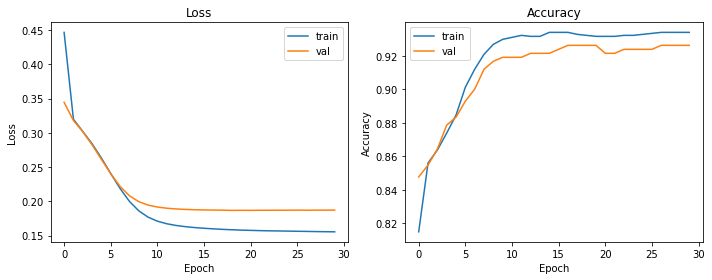

In [15]:
plot_history_simple(history)

Recopiez la cellule de votre `fit` dans la cellule suivante et regardez ce que cela donne sur vos courbes. Comparez vos courbes par rapport à la précédente ?Que constatez vous ? Quelles sont les raisons ?

Epoch 1/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9339 - loss: 0.1553 - val_accuracy: 0.9262 - val_loss: 0.1873
Epoch 2/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9339 - loss: 0.1552 - val_accuracy: 0.9262 - val_loss: 0.1872
Epoch 3/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9339 - loss: 0.1550 - val_accuracy: 0.9262 - val_loss: 0.1872
Epoch 4/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9339 - loss: 0.1548 - val_accuracy: 0.9262 - val_loss: 0.1872
Epoch 5/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9339 - loss: 0.1546 - val_accuracy: 0.9262 - val_loss: 0.1871
Epoch 6/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9339 - loss: 0.1544 - val_accuracy: 0.9262 - val_loss: 0.1870
Epoch 7/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9339 - loss: 0.1541 - val_accuracy: 0.9262 - val_loss: 0.1870
Epoch 8/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9339 - loss: 0.1539 - val_accuracy: 0.

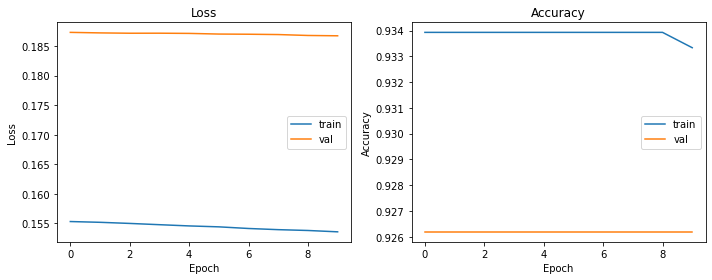

In [16]:
# Recopier votre cellule de fit en dessous

epochs=10

history = model.fit(
X_train,y_train,epochs=epochs, batch_size=16, validation_split=0.2, verbose=1


)

# conserver la ligne suivante
plot_history_simple(history)

Nous allons maintenant ajouter plus d'informations dans notre `fit`. Nous avons vu en cours qu'il ne fallait pas envoyer le jeu de données dans sa globalité mais plutôt partie par partie (*mini batch gradient descent*). En outre, nous avons vu qu'il était intéressant de reporter comment se comporte, pendant son apprentissage, le modèle en prédiction (i.e. un jeu de validation). Ici nous allons tricher un peu et prendre le jeu de test comme jeu de validation.  

Avant de faire ça recopiez dans la cellule suivante, votre définition du modèle et la compilation.

In [17]:

input_dim=2

# Recopiez votre modèle ici

learning_rate=1e-3
model.compile(optimizer=Adam(learning_rate), loss="binary_crossentropy",
              metrics=["accuracy"])

Modifiez votre `fit`de manière à introduire :    
- une taille de batch (`batchize=...`). Généralement une puissance de 2.
- un jeu de validation (`validation_data=(..,..)`).


In [18]:
batch_size= 64
epochs=60

history = model.fit(
    X_train,y_train,epochs=epochs, batch_size=batch_size, validation_split=0.2, verbose=1,validation_data=(X_test, y_test)

)

Epoch 1/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9324 - loss: 0.1588 - val_accuracy: 0.9400 - val_loss: 0.1532
Epoch 2/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9338 - loss: 0.1581 - val_accuracy: 0.9400 - val_loss: 0.1546
Epoch 3/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9352 - loss: 0.1574 - val_accuracy: 0.9411 - val_loss: 0.1544
Epoch 4/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9343 - loss: 0.1573 - val_accuracy: 0.9411 - val_loss: 0.1544
Epoch 5/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9343 - loss: 0.1571 - val_accuracy: 0.9411 - val_loss: 0.1544
Epoch 6/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9343 - loss: 0.1570 - val_accuracy: 0.9411 - val_loss: 0.1543
Epoch 7/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9343 - loss: 0.1568 - val_accuracy: 0.9411 - val_loss: 0.1544
Epoch 8/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9343 - loss: 0.1567 - val_accuracy: 0.9411 - val_loss:

Faites varier la taille de `batch_size` par exemple : 8, 16, 32, 64. Que constatez vous sur le déroulement de l'apprentissage ?   

Affichez l'historique, que constatez-vous sur la courbe de validation et d'apprentissage ?

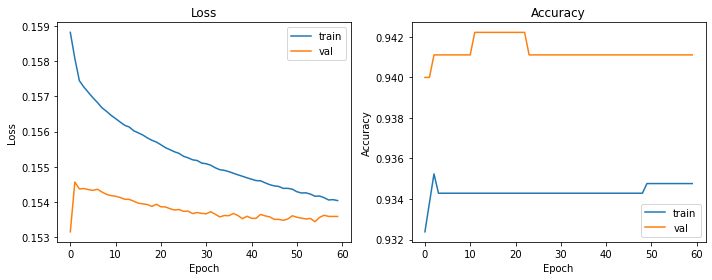

In [19]:
plot_history_simple(history)

Maintenant nous allons nettoyer un peu tout ça. Créér une fonction `define_model`qui prend quatre paramètres `input_dim`, `learning_rate`, `loss` et `metrics`. Dans cette fonction vous mettrez la définition de votre modèle, la création de votre modèle ainsi que sa compilation. A la sortie la fonction doit retourner le modèle créé.

In [20]:
def define_model(input_dim=2, learning_rate=1e-3,
                 loss="binary_crossentropy", metrics="accuracy"):
    
    inputs = Input(shape=(input_dim,))
    #1ere couche 
    x = Dense(32, activation="relu",name="1erecouche")(inputs)
    #2eme couche 
    x= Dense(32, activation="relu",name="2emecouche")(x)
    #relu = hidden_layer(layers intermediaires) , output non linéaire , peut être n'imp quelle valeur
    #sigmoid = output_layer , classification binaire, probabilité 

    outputs = Dense(1, activation="sigmoid",name="output_layer")(x)

    model = Model(inputs, outputs, name="model_simple")
    learning_rate=learning_rate
    model.compile(optimizer=Adam(learning_rate), loss=loss,
              metrics=[metrics])



    return model






Utilisez cette fonction pour apprendre votre modèle et afficher l'historique afin de voir si elle fonctionne bien.

Epoch 1/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8417 - loss: 0.4501 - val_accuracy: 0.8452 - val_loss: 0.3489
Epoch 2/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8524 - loss: 0.3234 - val_accuracy: 0.8571 - val_loss: 0.3247
Epoch 3/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8560 - loss: 0.3117 - val_accuracy: 0.8571 - val_loss: 0.3123
Epoch 4/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8625 - loss: 0.2999 - val_accuracy: 0.8690 - val_loss: 0.2983
Epoch 5/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8702 - loss: 0.2862 - val_accuracy: 0.8762 - val_loss: 0.2829
Epoch 6/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8810 - loss: 0.2705 - val_accuracy: 0.8786 - val_loss: 0.2661
Epoch 7/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8899 - loss: 0.2526 - val_accuracy: 0.8952 - val_loss: 0.2483
Epoch 8/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9024 - loss: 0.2319 - val_accuracy: 0.

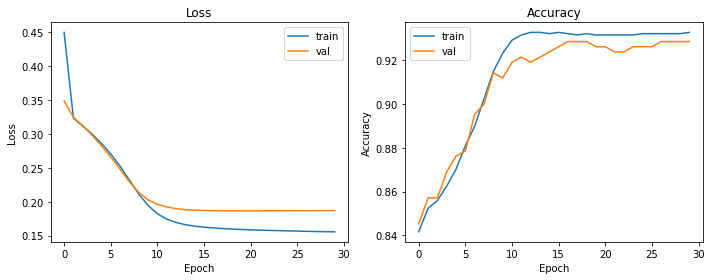

In [21]:
model=define_model()
history=model.fit(
X_train,y_train,epochs=30, batch_size=16, validation_split=0.2, verbose=1

)
plot_history_simple(history)

Une fois que le modèle a été appris, nous pouvons l'utiliser pour faire de la prédiction comme pour les "modèles traditionnels" à l'aide de `predict(...)`.  



In [22]:
# Complétez la cellule
y_pred_prob =model.predict(X_test)
y_pred = (y_pred_prob >= 0.5).astype(int)

# Affichage d'une valeur prédite
print (y_pred[1])

# Affichage du classification report
print(classification_report(y_test, y_pred,
                            target_names=["class 0", "class 1"], digits=3))

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
[1]
              precision    recall  f1-score   support

     class 0      0.959     0.924     0.941       450
     class 1      0.927     0.960     0.943       450

    accuracy                          0.942       900
   macro avg      0.943     0.942     0.942       900
weighted avg      0.943     0.942     0.942       900



Pourquoi est-ce que ça ne fonctionne pas ? pourquoi y a t'il une erreur ? regardez bien la valeur retournée. Réfléchissez avant de regarder la solution dans la cellule suivante.


La sortie du modèle est une `sigmoid` (classification binaire). Donc vous obtenez une probabilité et non pas 0 ou 1. Il est indispensable de convertir cette probabilité en 0 ou 1 pour `classification_report` ou pour une matrice de confusion.

              precision    recall  f1-score   support

     class 0      0.959     0.924     0.941       450
     class 1      0.927     0.960     0.943       450

    accuracy                          0.942       900
   macro avg      0.943     0.942     0.942       900
weighted avg      0.943     0.942     0.942       900



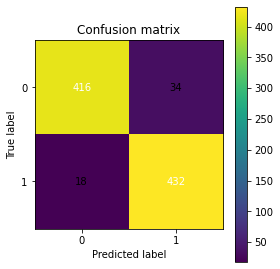

In [24]:
# Conversion de la probabilité en binaire
y_prob = model.predict(X_test, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print(classification_report(y_test, y_pred,
                            target_names=["class 0", "class 1"],
                            digits=3))

plot_confusion_matrix_simple(y_test, y_pred, labels=(0,1), normalize=None)

Maintenant jouez un peu avec les paramètres : nombre de couches, nombre de neurones dans les couches, batchsize, learning rate, etc. pour voir l'impact que ça a sur vos courbes mais également sur la prédiction.   
N'oubliez pas de bien redéfinir votre modèle et sa compilation avant de faire un `fit` sinon votre modèle va conserver les poids de l'apprentissage précédent ... c'était la réponse à une question précédente où quand on examine les courbes on voit que la loss, sans redéfinition du modèle, repars de la loss obtenue à l'apprentissage précédent car les poids ont été appris.

## Un réseau de neurones dans une bonne chaine de traitement

Dans l'étape précédente, nous avons réalisé une simple expérimentation après avoir fait un `train_test_split`. Vous savez qu'on ne peut pas tirer de conclusions d'un seul essai et qu'il est indispensable de faire de la cross validation.   

Dans cette section, nous réalisons une chaîne de traitement complète dans laquelle nous expérimentons en cross validation, nous finalisons le modèle final et nous le sauvegardons pour faire un modèle qui puisse être mis en production.

Comme précédemment nous commençons par créer le jeu de données. Puis nous créons un jeu d'apprentissage et un jeu de test. Le jeu de test `X_test` ne sera utilisé qu'à la fin pour faire un `predict` final du modèle avant de passer en production. Nous utiliserons `X_train` pour la partie cross validation, i.e. c'est à partir de ce `X_train` qu'à chaque fold nous allons créer un jeu d'apprentissage et un jeu de validation.



In [ ]:
X, y = make_moons(n_samples=3000, noise=0.25, random_state=42)

# train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

Nous avons à présent trois jeux de données :    
- `X_train` sur lequel on effectuera l'apprentissage. C'est lui qui servira dans la cross validation

- `X_test` qui sera utilisé pour faire de la prédiction au final et voir le comportement du modèle sur des données qu'il n'a jamais vu.

Dans la cellule suivante écrivez le code pour normaliser les données. Attention n'oubliez pas ce que vous avez vu avant.

In [ ]:
# Complétez la cellule

scaler = StandardScaler() #normalisation
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test= scaler.transform(X_test)

Pour vous simplifiez la vie, recopiez dans la cellule suivante la fonction `define_model` réalisée précédemment.

In [ ]:
def define_model(input_dim=2, learning_rate=1e-3,
                 loss="binary_crossentropy", metrics="accuracy"):

    inputs = Input(shape=(input_dim,))
    #1ere couche 
    x = Dense(32, activation="relu",name="1erecouche")(inputs)
    #2eme couche 
    x= Dense(32, activation="relu",name="2emecouche")(x)
    #relu = hidden_layer(layers intermediaires) , output non linéaire , peut être n'imp quelle valeur
    #sigmoid = output_layer , classification binaire, probabilité 

    outputs = Dense(1, activation="sigmoid",name="output_layer")(x)

    model = Model(inputs, outputs, name="model_simple")
    learning_rate=learning_rate
    model.compile(optimizer=Adam(learning_rate), loss=loss,
              metrics=[metrics])



    return model



Nous définissons quelques variables globales pour la suite. N'oubliez pas que vous pouvez/devez vous entraîner à les faire varier pour voir l'influence qu'elles peuvent avoir sur votre entraînement.

In [ ]:
# Pour la définition du modèle
input_dim=2
learning_rate=1e-3
loss="binary_crossentropy"
metrics="accuracy"

# Pour l'apprentissage
batch_size=64
epochs=30
verbose=0

# Pour le nombre de folds
n_splits=5

Nous allons, à présent, faire la cross validation.


In [39]:
# Complétez le code

cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
cv_scores = [] # Pour récupérer les scores des folds
all_histories = [] # Pour récupérer les historiques des folds

# Récupération des folds
for fold, (tr_idx, va_idx) in enumerate(cv.split(X_train, y_train), 1):
    X_train_in_fold, X_val_in_fold = X_train[tr_idx], X_train[va_idx]
    y_train_in_fold, y_val_in_fold = y_train[tr_idx], y_train[va_idx]

    # Attention il faut normaliser
    scaler = StandardScaler() #normalisation
    #scaler.fit(X_train_in_fold)
    X_train_in_fold = scaler.fit_transform(X_train_in_fold)
    X_val_in_fold= scaler.transform(X_val_in_fold)


    # Definition du modèle
    model_fold = define_model()
    # Apprentissage
    history = model_fold.fit(
        X_train_in_fold,y_train_in_fold,epochs=epochs, batch_size=batch_size, validation_split=0.2, verbose=verbose,validation_data=(X_val_in_fold, y_val_in_fold)


    )

    # Evaluation
    y_prob_fold = model_fold.predict(X_val_in_fold, verbose=0).ravel()
    y_va_pred = (y_prob_fold >= 0.5).astype(int)

    acc = accuracy_score(y_val_in_fold, y_va_pred)

    cv_scores.append(acc)
    print(f"Fold {fold}: val accuracy = {acc:.3f}")

    # Sauvegarde des historiques pour l'affichage
    hist_df = pd.DataFrame(history.history)
    hist_df["epoch"] = range(1, len(hist_df) + 1)
    hist_df["fold"]  = fold
    all_histories.append(hist_df)

# Affichage des résultats
hist_cv_df = pd.concat(all_histories, ignore_index=True)
last = hist_cv_df.sort_values(["fold", "epoch"]).groupby("fold").tail(1)

train_mean = last["accuracy"].mean()
train_std  = last["accuracy"].std()
val_mean   = last["val_accuracy"].mean()
val_std    = last["val_accuracy"].std()

print("Train accuracy (last epoch):", round(train_mean, 3), "±",
      round(train_std, 3))
print("Val   accuracy (last epoch):", round(val_mean, 3),   "±",
      round(val_std, 3))

Epoch 1/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.5000 - loss: 0.6537 - val_accuracy: 0.5017 - val_loss: 0.6105
Epoch 2/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5467 - loss: 0.5888 - val_accuracy: 0.7258 - val_loss: 0.5542
Epoch 3/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8033 - loss: 0.5368 - val_accuracy: 0.8358 - val_loss: 0.5087
Epoch 4/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8400 - loss: 0.4952 - val_accuracy: 0.8400 - val_loss: 0.4714
Epoch 5/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8425 - loss: 0.4600 - val_accuracy: 0.8475 - val_loss: 0.4389
Epoch 6/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8483 - loss: 0.4290 - val_accuracy: 0.8517 - val_loss: 0.4095
Epoch 7/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8500 - loss: 0.4004 - val_accuracy: 0.8550 - val_loss: 0.3819
Epoch 8/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8500 - loss: 0.3752 - val_accuracy: 0.

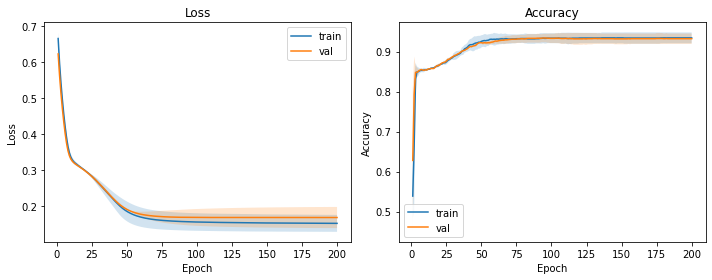

In [41]:
plot_history_cv_mean_std(all_histories)

Maintenant nous allons changer quelques paramètres en mettant des valeurs un peu extrème et voir ce qui se passe. Pensez à non seulement examiner la courbe mais également les dernières valeurs des epochs pour chaque fold. Ici volontairement nous ne mettons que deux folds mais nous étendons le nombre d'epochs. Considérez les paramètres suivants et relancer votre cross validation avec ces derniers. Vous pouvez recopier en dessous la cellule de cross validation ou la ré-exécuter (comme ici le modèle est créé à chaque fold il n'y aura pas de problèmes). Que constatez vous après avoir relancé la cross validation ?

In [42]:
# Pour l'apprentissage
batch_size=128
epochs=200
verbose=1

# Pour le nombre de folds
n_splits=2

En regardant attentivement on peut constater que la val_loss n'évolue plus alors que la loss peut encore diminuer. Ceci est un début de surapprentissage. Le modèle essaye d'apprendre par coeur le jeu de données d'apprentissage et n'arrive pas à bien prédire un jeu qu'il n'a pas vu (le jeu de validation). Il n'est pas nécessaire de continuer un apprentissage si pendant quelques epochs la val_loss n'évolue pas.   
Pour éviter le sur-apprentissage, on peut arrêter automatiquement l'entraînement quand une mesure de validation n'améliore plus. On utilise un callback `EarlyStopping` : c'est une fonction associé à l'entrainement et appelée automatiquement à la fin de chaque epoch. Elle surveille une métrique (par ex. val_loss) et, si elle n'améliore pas pendant patience epochs, elle stoppe l'entraînement. Avec restore_best_weights=True, le modèle revient aux meilleurs poids observés. Résultat : moins d'epochs inutiles (et moins de CO₂ :) ).
```python
es = EarlyStopping(
    monitor="val_loss",      # ou "val_accuracy"
    patience=5,             # nb d'epochs sans amélioration avant arrêt
    min_delta=0.0,           # amélioration minimale à considérer
    mode="min",              # "min" pour une loss, "max" pour une accuracy
    restore_best_weights=True,
    verbose=1
)
```
et au niveau du `fit` il suffit d'appeler cette fonction callback :
```python
history = model.fit(
    ...
    callbacks=[es],
    ...
)
```

**Remarque :** il existe différentes fonctions callback qui peuvent être utilisée. Par exemple `ModelCheckPoint` qui permet de sauvegarder à chaque étape le modèle et donc pouvoir reprendre un apprentissage en cas de problème (voir Guide Réseaux de Neurones - "Les réseaux de neurones avec Keras").   

Recopiez dans la cellule suivante votre code de cross validation et effectuez les modifications pour intégrer un early stopping. Relancez l'apprentissage avec les valeurs importantes d'epochs. Quand s'arrête l'apprentissage ?

**Attention :** la fonction de plot des courbes risque de ne plus fonctionner car elle considère qu'à chaque fold il y a le même nombre d'epochs.

In [43]:
# Complétez le code

cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
cv_scores = []
all_histories = [] # Pour récupérer les historiques des folds

# Récupération des folds
for fold, (tr_idx, va_idx) in enumerate(cv.split(X_train, y_train), 1):
    X_train_in_fold, X_val_in_fold = X_train[tr_idx], X_train[va_idx]
    y_train_in_fold, y_val_in_fold = y_train[tr_idx], y_train[va_idx]

    # Attention il faut normaliser
    scaler = StandardScaler() #normalisation:
    #scaler.fit(X_train_in_fold)
    X_train_in_fold = scaler.fit_transform(X_train_in_fold)
    X_val_in_fold= scaler.transform(X_val_in_fold)


    # Definition du modèle

    model_fold = define_model()


    # Déclaration du Early Stopping
    es = EarlyStopping(
    monitor="val_loss",      # ou "val_accuracy"
    patience=5,             # nb d'epochs sans amélioration avant arrêt
    min_delta=0.0,           # amélioration minimale à considérer
    mode="min",              # "min" pour une loss, "max" pour une accuracy
    restore_best_weights=True,
    verbose=1
    )

    # Apprentissage
    history = model_fold.fit(
        X_train_in_fold,y_train_in_fold,epochs=epochs, batch_size=batch_size, validation_split=0.2, verbose=verbose,validation_data=(X_val_in_fold, y_val_in_fold),callbacks=[es]


    )

    # Evaluation
    #y_val_in_fold = model_fold.predict(X_val_in_fold, verbose=0).ravel()
    y_va_pred = (y_prob_fold >= 0.5).astype(int)


    acc = accuracy_score(y_val_in_fold, y_va_pred)
    cv_scores.append(acc)
    print(f"Fold {fold}: val accuracy = {acc:.3f}")

    # Sauvegarde des historiques pour l'affichage
    hist_df = pd.DataFrame(history.history)
    hist_df["epoch"] = range(1, len(hist_df) + 1)
    hist_df["fold"]  = fold
    all_histories.append(hist_df)

# Affichage des résultats
hist_cv_df = pd.concat(all_histories, ignore_index=True)
last = hist_cv_df.sort_values(["fold", "epoch"]).groupby("fold").tail(1)

train_mean = last["accuracy"].mean()
train_std  = last["accuracy"].std()
val_mean   = last["val_accuracy"].mean()
val_std    = last["val_accuracy"].std()

print("Train accuracy (last epoch):", round(train_mean, 3), "±",
      round(train_std, 3))
print("Val   accuracy (last epoch):", round(val_mean, 3),   "±",
      round(val_std, 3))

Epoch 1/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.7117 - loss: 0.6075 - val_accuracy: 0.7967 - val_loss: 0.5659
Epoch 2/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7992 - loss: 0.5454 - val_accuracy: 0.8208 - val_loss: 0.5115
Epoch 3/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8133 - loss: 0.4945 - val_accuracy: 0.8258 - val_loss: 0.4645
Epoch 4/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8258 - loss: 0.4508 - val_accuracy: 0.8325 - val_loss: 0.4250
Epoch 5/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8342 - loss: 0.4149 - val_accuracy: 0.8383 - val_loss: 0.3930
Epoch 6/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8375 - loss: 0.3863 - val_accuracy: 0.8383 - val_loss: 0.3680
Epoch 7/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8425 - loss: 0.3643 - val_accuracy: 0.8417 - val_loss: 0.3493
Epoch 8/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8458 - loss: 0.3487 - val_accuracy: 0.

Maintenant relancer vos modèles avec de bonnes valeurs de manière à obtenir un bon modèle et évaluez le sur le jeu de test `X_test`.

In [44]:
y_test_pred = (model.predict(X_test, verbose=0).ravel() >= 0.5).astype(int)
test_acc = accuracy_score(y_test, y_test_pred)
print("Test accuracy =", round(test_acc, 3))

Test accuracy = 0.947


Comparez le résultat obtenu par rapport à l'accuracy du modèle que vous avez appris. Votre résultat pourrait être mauvais car en fait il y a un problème. En fait là vous avez de la chance. Quelles sont les raisons qui pourraient faire que vous ayez un mauvais résultat ? Dans la cellule suivante, corrigez l'erreur et évaluez à nouveau le jeu de test.

In [45]:
epochs=100
batchsize=128
n_splits=2

Ca y est nous avons trouvé un modèle performant (enfin si vous avez bien fait vos expérimentations :) ) et il ne reste plus qu'à le préparer pour le mettre en prédiction. Il n'est donc plus nécessaire d'avoir un jeu d'apprentissage et de test et nous pouvons travailler directement sur X. Créez un pipeline qui permet de faire la normalisation et d'exécuter le modèle. Vous sauvegarderez le pipeline à l'aide de `joblib` sous le nom "pipeline.joblib".

In [46]:
# Pour la définition du modèle
input_dim=2
learning_rate=1e-3
loss="binary_crossentropy"
metrics="accuracy"

# Pour l'apprentissage
batch_size=128
epochs=40
verbose=1

pipe = Pipeline([
('reduce_dim', StandardScaler()), ('clf', model_fold)])

es = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True, verbose=1)


# Fit sur tout X, y (modèle “final”)
# clf__ permet de passer les paramètres au fit
# clf__validation_split pour faire un jeu de validation à la volée
pipe.fit(X, y,
        clf__epochs=epochs,
        clf__batch_size=batch_size,
        clf__verbose=verbose,
        clf__validation_split=0.2,
        clf__callbacks=[es])


joblib.dump(pipe, "pipeline.joblib")


Epoch 1/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9337 - loss: 0.1595 - val_accuracy: 0.9450 - val_loss: 0.1362
Epoch 2/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9317 - loss: 0.1589 - val_accuracy: 0.9483 - val_loss: 0.1357
Epoch 3/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9312 - loss: 0.1586 - val_accuracy: 0.9467 - val_loss: 0.1357
Epoch 4/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9317 - loss: 0.1584 - val_accuracy: 0.9467 - val_loss: 0.1356
Epoch 5/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9317 - loss: 0.1583 - val_accuracy: 0.9467 - val_loss: 0.1356
Epoch 6/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9317 - loss: 0.1581 - val_accuracy: 0.9467 - val_loss: 0.1356
Epoch 7/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9317 - loss: 0.1580 - val_accuracy: 0.9467 - val_loss: 0.1356
Epoch 8/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9317 - loss: 0.1579 - val_accuracy: 0.9450 - val_loss

['pipeline.joblib']

Avant de tester notre modèle, nous pouvons afficher la frontière de décision et voir concrétement ce que ça donne.

1792/1792 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


/home/kanzy/.local/lib/python3.10/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


<AxesSubplot:title={'center':'Frontière de décision (NN + StandardScaler, make_moons)'}, xlabel='x1', ylabel='x2'>

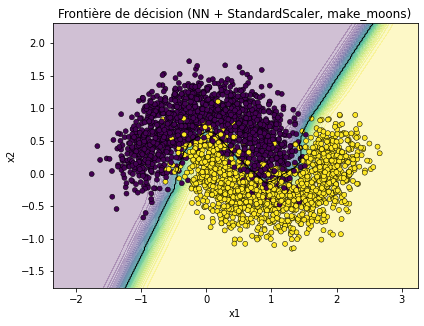

In [47]:
plot_decision_boundary(pipe, X, y,
                       title="Frontière de décision (NN + StandardScaler, make_moons)",
                       h=0.02, padding=0.6, threshold=0.5)

Maintenant nous effectuons un dernier traitement pour voir si le pipeline a bien été sauvegardé et fonctionne correctement. Comme jeu pour tester, nous générons des données assez similaires aux précédentes.

In [48]:
X_new, y_new = make_moons(n_samples=600, noise=0.25, random_state=47)

# Chargement du pipeline
pipe = joblib.load("pipeline.joblib")

# Prediction
y_prob = model.predict(X_new, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print("Accuracy (new data):", round(accuracy_score(y_new, y_pred), 3))

Accuracy (new data): 0.758


# Les CNN

A présent, nous allons voir comment utiliser des convolutions sur des images. Rappelez vous que le rôle des convolutions au départ est de "traiter" les images pour en extraire des parties utiles pour la classification qui se déroule à la fin de votre modèle.

# Le jeu de données

Pour apprendre à faire des CNN, nous allons utiliser un jeu de données qui contient des images d'animaux. En fait il y a trois catégories d'animaux : des tigres, des éléphants et des renards. Vous pouvez choisir celui qui vous plaît le plus. Ils sont tous définis de la même manière.

Normalement dans la section Installation, vous avez sauvegarder le jeu de données dans votre répertoire courant.   

Pour chacun d'entre eux il y a un ensemble d'images positive et un ensemble d'images négatives. Par exemple dans le répertoire *tiger* il n'y a que des images de tigre et dans le répertoire *Tiger_negative_class* il n'y a que des images d'animaux qui ne correspondent pas à des tigres.    


Le code ci-dessous permet de visualiser quelques images contenues dans le répertoire *elephant*.

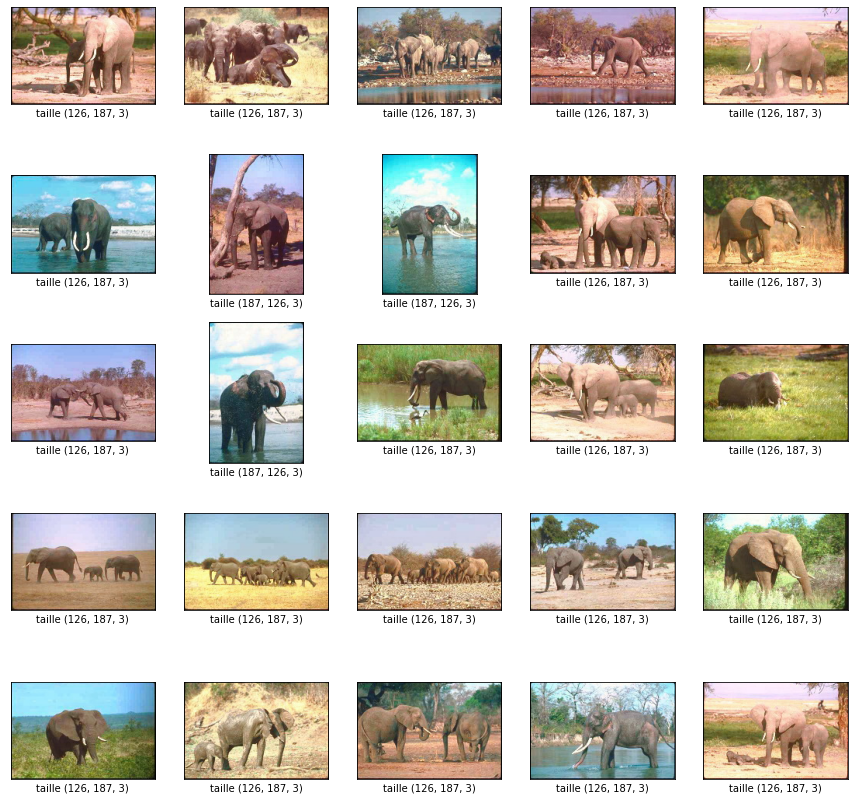

In [49]:
from os import listdir
from os.path import isfile, join


mypath='Data_Project/Tiger-Fox-Elephant/elephant'
onlyfiles = [ f for f in listdir(mypath) if isfile(join(mypath,f)) ]
images = np.empty(len(onlyfiles), dtype=object)
for n in range(0, len(onlyfiles)):
  images[n] = cv2.imread( join(mypath,onlyfiles[n]) )


nb_columns = 25 # Nombre d'images à afficher

plt.figure(figsize=(15,15))
for i in range(nb_columns):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    # cv2 lit met les images en BGR et matplotlib lit du RGB
    # il faut donc convertir pour afficher les bonnes couleurs
    images[i] = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)
    plt.imshow(images[i],cmap=plt.cm.binary)
    plt.xlabel('taille ' + str(images[i].shape))

Nous pouvons constater que les images ne sont pas de la même taille. Il faut donc les convertir. Une manière simple de faire et de faire la conversion lors de la lecture des images : ici nous convertissons toutes les images en 128x128.

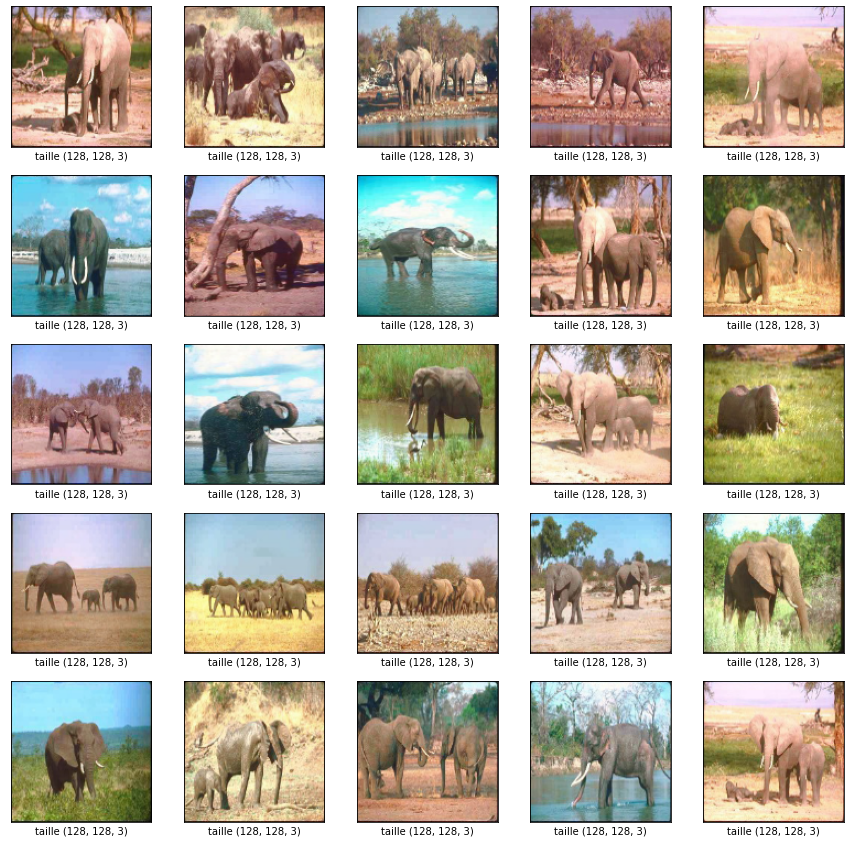

In [50]:
IMG_SIZE=128
mypath='Data_Project/Tiger-Fox-Elephant/elephant'
onlyfiles = [ f for f in listdir(mypath) if isfile(join(mypath,f)) ]
images = np.empty(len(onlyfiles), dtype=object)
for n in range(0, len(onlyfiles)):
  images[n] = cv2.imread( join(mypath,onlyfiles[n]) )
  images[n]  = cv2.resize(images[n], (IMG_SIZE, IMG_SIZE))

plt.figure(figsize=(15,15))
for i in range(nb_columns):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    # cv2 lit met les images en BGR et matplotlib lit du RGB
    # il faut donc convertir pour afficher les bonnes couleurs
    images[i] = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)
    plt.imshow(images[i],cmap=plt.cm.binary)
    plt.xlabel('taille ' + str(images[i].shape))

Actuellement pour chaque animal nous avons un répertoire qui contient des images positives et un répertoire qui contient des images négatives. Pour pouvoir créer un jeu de données nous devons obtenir X et y. Les fonctions ci-dessous permettent de générer, à partir des répertoires, un jeu de données aléatoire pour X et y.

In [64]:
def create_training_data(path_data, list_classes):
  training_data=[]
  for classes in list_classes:
      path=os.path.join(path_data, classes)
      class_num=list_classes.index(classes)
      for img in os.listdir(path):
        try:
          img_array = cv2.imread(os.path.join(path,img), cv2.IMREAD_UNCHANGED)
          new_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
          training_data.append([new_array, class_num])
        except Exception as e:
          pass
  return training_data

def create_X_y (path_data, list_classes):
      # récupération des données
      training_data=create_training_data(path_data, list_classes)
      # tri des données
      random.shuffle(training_data)
      # création de X et y
      X=[]
      y=[]
      for features, label in training_data:
        X.append(features)
        y.append(label)
      X=np.array(X).reshape(-1,IMG_SIZE, IMG_SIZE, 3)
      y=np.array(y)
      return X,y

Pour créer un jeu de données il suffit d'appeler ces fonctions. Par la suite, nous utiliserons les éléphants mais bien sûr vous pouvez utiliser ce que vous voulez.

Nombre de données :  200
Taille d'une image pour connaître l'input du réseau (128, 128, 3)
Distribution des labels dans le jeu d'apprentissage
Nombre d'éléments par classe 0    100
1    100
Name: count, dtype: int64


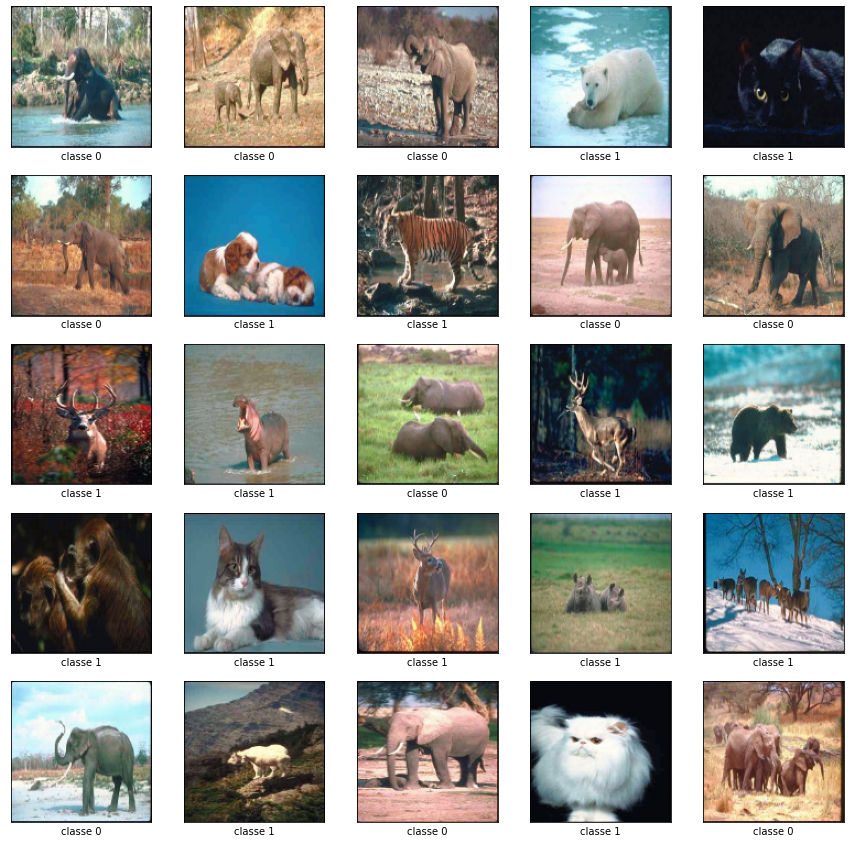

In [65]:
my_path="Data_Project/Tiger-Fox-Elephant/"
my_classes=['elephant','Elephant_negative_class']
X,y=create_X_y (my_path,my_classes)


# Affichage d'exemples
plot_examples(X,y)

# Quelques informations sur les données
print ("Nombre de données : ",X.shape[0])
print ("Taille d'une image pour connaître l'input du réseau", X[0].shape)
print ("Distribution des labels dans le jeu d'apprentissage")
print("Nombre d'éléments par classe", pd.Series(y).value_counts())

Maintenant il faut normaliser. Nous avons vu précédemment qu'il fallait faire attention à la normalisation : faire un `.fit(X_train)`et après un `.transform(...)` sur le `X_train` et le `X_test`. Là nous travaillons sur des images qui possèdent toutes des valeurs de pixels entre 0 et 255 (sur les 3 canaux R,G et B) donc il ne devrait pas y avoir trop de surprise entre les jeux de données. Nous pouvons donc simplement normaliser de la manière suivante :  

In [67]:
X=X.astype('float')
X=X/255.0

# Un premier CNN

Comme précédemment nous allons créer un premier CNN simple avec un apprentissage uniquement sur un jeu de `X_train` et `X_test`, i.e. sans cross validation.  

Votre premier modèle doit contenir une couche de convolution, une couche de maxpooling, une couche de flatten et une couche dense. Utilisez la notation fonctionnelle. Attention aux fonctions d'activation et n'oubliez pas de nommer vos couches. Respectez les conventions :    
- la première couche est `input = ...`
- la dernière couche est `output = ...`



In [98]:
# Complétez la cellule
image_size=128

###
###inputs = Input(shape=(2,))
#1ere couche 
##x = Dense(32, activation="relu",name="1erecouche")(inputs)
#2eme couche 
##x= Dense(32, activation="relu",name="2emecouche")(x)
#relu = hidden_layer(layers intermediaires) , output non linéaire , peut être n'imp quelle valeur
#sigmoid = output_layer , classification binaire, probabilité 

##outputs = Dense(1, activation="sigmoid",name="output_layer")(x)

###
# 1 - Convolutional Layer
inputs = Input(shape=(128, 128, 3))


conv= Conv2D(4, (3, 3), activation='relu') (inputs)
    # 2 - Max-Pooling Layer
maxpool = MaxPooling2D(pool_size=(2, 2)) (conv)
    # 3 - Flatten Layer
flatten = Flatten() (maxpool)
    # 5 - Output Layer
output= Dense(1, activation='softmax') (flatten)

model = Model(inputs=inputs, outputs=output, name="cnn_minimal")

Après avoir créé votre modèle, vous pouvez le compiler de la même manière que précédemment :   

In [99]:
model.compile(optimizer=Adam(1e-3),
              loss="binary_crossentropy",
              metrics=["accuracy"])

Affichez la structure du modèle pour voir le nombre de paramètres à apprendre. Que constatez vous ?

In [100]:
model.summary()

Model: "cnn_minimal"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_30 (InputLayer)     │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 126, 126, 4)    │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 63, 63, 4)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 15876)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │        15,877 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,989 (62.46 KB)

 Trainable params: 15,989 (62.46 KB)

 Non-trainable params: 0 (0.00 B)

Maintenant crééz un jeu de train et de test. N'oubliez pas que les données ont déjà été normalisée. Apprenez le modèle. Comme jeu de validation vous prendrez 20% du jeu passé en paramètre. Affichez les courbes obtenues ainsi la prédiction sur X_test.

In [1]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
# Entraînement
epochs = 40
batch_size = 32
history = model.fit(
    X_train,y_train,epochs=epochs, batch_size=batch_size, validation_split=0.2, verbose=1


)

# Courbes loss/accuracy
plot_history_simple(history)

# Évaluation sur X_test
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print("Test accuracy:", round(test_acc, 3))
y_pred_prob =model.predict(X_test)
y_pred = (y_pred_prob >= 0.5).astype(int)

# Affichage d'une valeur prédite
print (y_pred[1])

# Affichage du classification report
print(classification_report(y_test, y_pred,
                            target_names=["class 0", "class 1"], digits=3))

NameError: name 'train_test_split' is not defined

Que constatez vous ? Testez plusieurs solutions pour essayer d'améliorer les choses. Intuition : `Dropout`, `BatchNormalization`, `EarlyStopping`, etc. N'hésitez pas à regarder le *guide sur les images* et le *guide sur les réseaux de neurones* où vous trouverez de nombreuses pistes.

A la fin, en vous inspirant de ce que vous avez fait dans la première partie, proposez une chaîne de traitement complète avec cross validation.